**1. Setup**

%pip install numpy pandas scikit-learn matplotlib seaborn -q

In [1]:
%pip install numpy pandas scikit-learn matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**2. Load Data & clean**

**Breast Cancer Wisconsin (Diagnostic) Dataset**

A binary classification dataset used to predict whether a breast tumor is malignant or benign based on numeric features extracted from biopsy images.
- ~570 samples
- 30 numerical features
- Target: malignant vs benign

In [3]:
df = pd.read_csv("breast_cancer_dataset.csv")

In [4]:
df.shape

(569, 32)

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [7]:
# check if there is any missing values
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [8]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [10]:
df["diagnosis"].value_counts(normalize=True)*100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [11]:
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

In [12]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [15]:
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


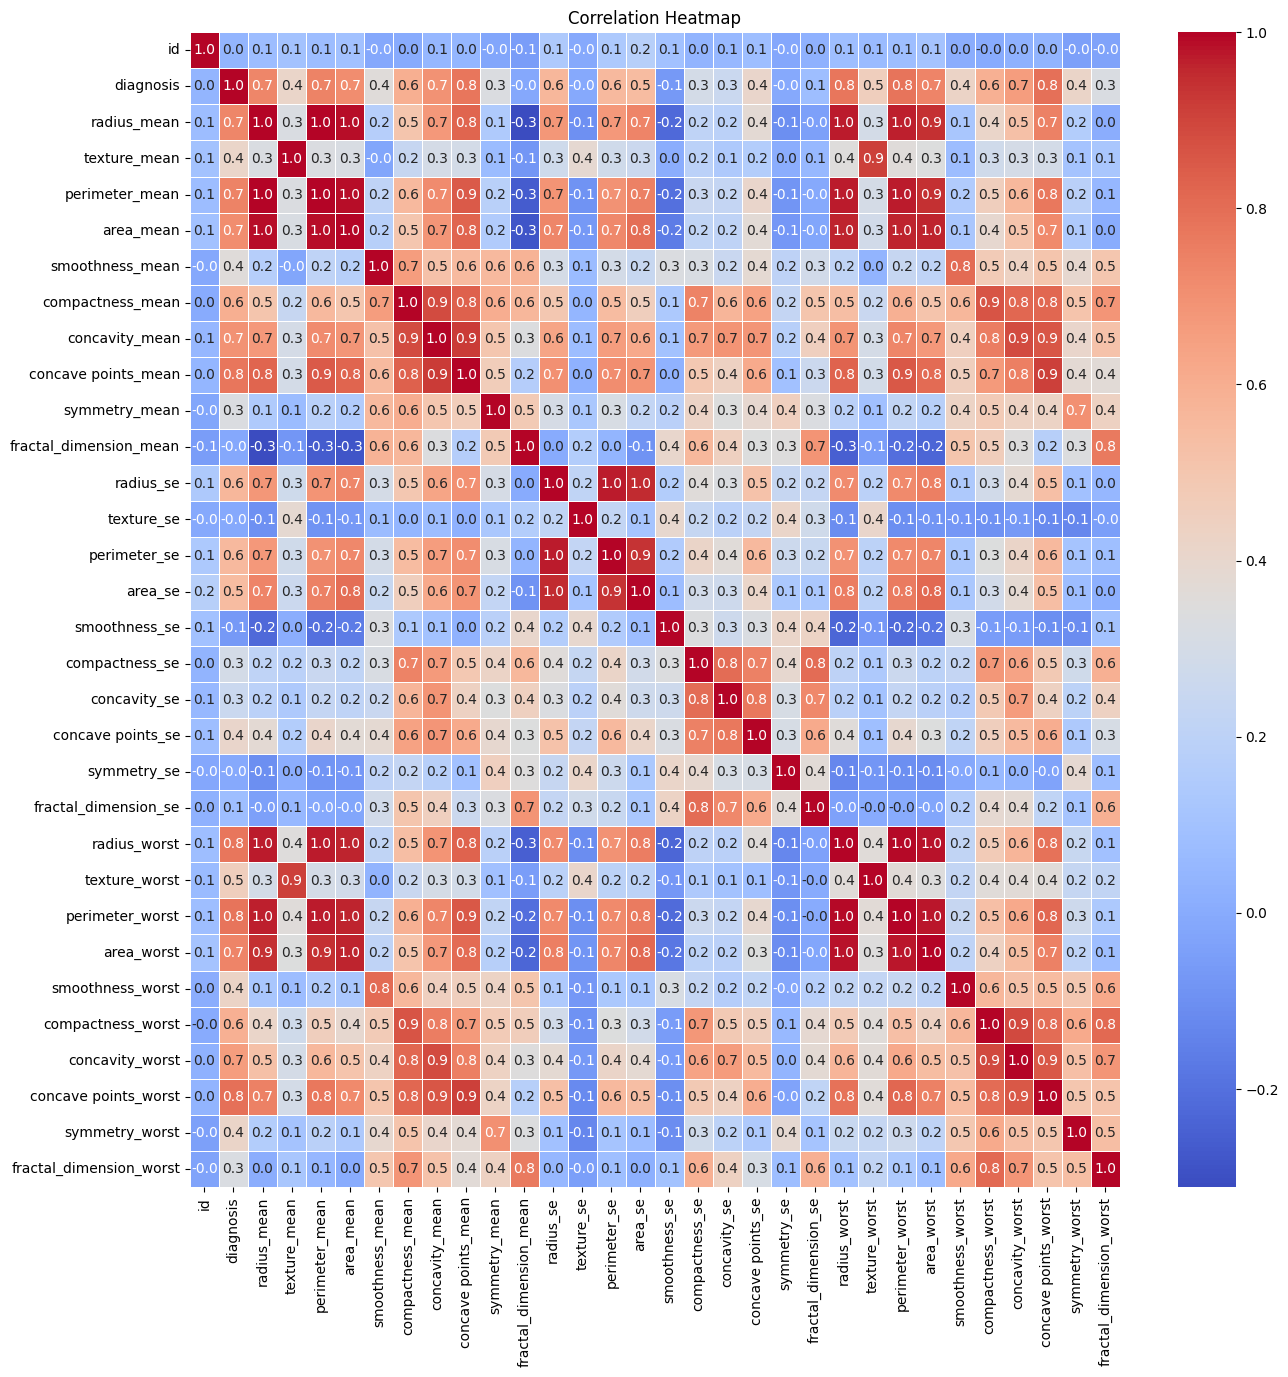

In [16]:
df_corr = df.corr()

# plot the heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".1f",
    linewidth=0.5,
    cbar=True
)

plt.title("Correlation Heatmap")
plt.show()

**NOTE: There are presence of highly correlated features**

**3. Split data into features ad target**

In [17]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

In [18]:
X[:5]

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [19]:
y[:5]

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

**4. Train Test Split**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [21]:
print("Dataset size:", X.shape)
print("Train Dataset size:", X_train.shape)
print("Test Dataset size:", X_test.shape)

Dataset size: (569, 30)
Train Dataset size: (455, 30)
Test Dataset size: (114, 30)


**5. Feature Selection Process**

In [22]:
# helper function to print train and test metrics
def print_metrics(name, model, Xtr, Xte, ytr, yte):

    # get predictions
    tr_pred = model.predict(Xtr)
    te_pred = model.predict(Xte)

    # get accuracy
    tr_acc = accuracy_score(ytr, tr_pred)
    te_acc = accuracy_score(yte, te_pred)

    print(name)
    print(f"Train Accuracy: {round(tr_acc*100, 2)} %")
    print(f"Test Accuracy: {round(te_acc*100, 2)} %")

**Baseline model (no features removed)**

In [23]:
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

In [24]:
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
print_metrics(
    name="Baseline model (All features)",
    model=baseline_pipe,
    Xtr=X_train,
    Xte=X_test,
    ytr=y_train,
    yte=y_test
)

Baseline model (All features)
Train Accuracy: 98.68 %
Test Accuracy: 96.49 %


**Filter Method: Correlation**

In [ ]:
corr = X_train.corr().abs()  # identify both highly positively correlated and negatively correlated columns

to_drop = set()

for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] > 0.9:
            to_drop.add(corr.columns[i])

print("Columns to drop:", to_drop)
#comprehension to create a list using for loop c: columns
selected_filter = [c for c in X_train.columns if c not in to_drop]
print("Selected columns:", selected_filter)

Columns to drop: {'area_se', 'radius_worst', 'concave points_mean', 'area_worst', 'perimeter_se', 'perimeter_mean', 'area_mean', 'perimeter_worst', 'texture_worst', 'concave points_worst'}
Selected columns: ['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [31]:
#comparing each col with other cols
for i in range(len(corr.columns)):
    for j in range(i):
        print(X_train.columns[i],X_train.columns[j])

texture_mean radius_mean
perimeter_mean radius_mean
perimeter_mean texture_mean
area_mean radius_mean
area_mean texture_mean
area_mean perimeter_mean
smoothness_mean radius_mean
smoothness_mean texture_mean
smoothness_mean perimeter_mean
smoothness_mean area_mean
compactness_mean radius_mean
compactness_mean texture_mean
compactness_mean perimeter_mean
compactness_mean area_mean
compactness_mean smoothness_mean
concavity_mean radius_mean
concavity_mean texture_mean
concavity_mean perimeter_mean
concavity_mean area_mean
concavity_mean smoothness_mean
concavity_mean compactness_mean
concave points_mean radius_mean
concave points_mean texture_mean
concave points_mean perimeter_mean
concave points_mean area_mean
concave points_mean smoothness_mean
concave points_mean compactness_mean
concave points_mean concavity_mean
symmetry_mean radius_mean
symmetry_mean texture_mean
symmetry_mean perimeter_mean
symmetry_mean area_mean
symmetry_mean smoothness_mean
symmetry_mean compactness_mean
symmetr

In [27]:
print(len(to_drop))
print(len(selected_filter))

10
20


In [28]:
X_train_f = X_train[selected_filter]
X_test_f = X_test[selected_filter]

In [32]:
filter_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

In [33]:
filter_pipe.fit(X_train_f, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['radius_mean','texture_mean','smoothness_mean',...,'concavity_worst', 'symmetry_worst','fractal_dimension_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [34]:
print_metrics(
    name="Baseline model (All features)",
    model=filter_pipe,
    Xtr=X_train_f,
    Xte=X_test_f,
    ytr=y_train,
    yte=y_test
)

Baseline model (All features)
Train Accuracy: 98.68 %
Test Accuracy: 97.37 %


**GOAL:** Remove highly correlated features so the model does not get confused.

**STEP 1: CORRELATION:**

Compute correlation between all feature pairs.
Take absolute value so +0.95 and -0.95 are treated the same.

**STEP 2: INITIALIZE:**

Create an empty set `to_drop` to store columns that should be removed.

**STEP 3: FOR-LOOP LOGIC:**

For each column i:

    Compare it with all previous columns (j < i)
  
    If correlation(i, j) > 0.9:
  
        Mark column i to be dropped

Why this works:
- Avoids duplicate comparisons
- Avoids comparing a column with itself
- Keeps the earlier column, drops the later one

**STEP 4: FILTER COLUMNS:**

Keep only columns not present in `to_drop`.

**STEP 5: TRAIN MODEL:**

Scale features → Train Logistic Regression → Evaluate performance.

**FLOW:**

Start
 → Check feature correlations
 → Drop highly similar features
 → Train model on cleaned data
 → Evaluate results